# D2: Data Ingestion & Processing Pipeline - Data Acquisition, Analysis, Wrangling, Feature Engineering 

## Author: Yousef Hussein




## <span style="color:#0B6E4F;">D2.1: Data Acquisition</span>


### Data Acquisition Summary

This project builds a multimodal dataset for NVIDIA (NVDA) to predict whether Polymarket odds move **UP** or **DOWN** over the next 24 hours.

Data is collected on a trading-day basis, with timestamps normalized to US Eastern Time. News text, market context features, and Polymarket odds history are also used as a source of data.

### Data Sources

#### **Source 1: Finviz news**
Finviz provides timely headlines that feed the sentiment pipeline. For historical coverage, archived Finviz snapshots are discovered through the Wayback CDX API and then parsed for headline records.
- Access method: query the Wayback CDX API for historical Finviz snapshot URLs, then scrape archived pages with basic rate limiting.
- Fields: headline, source, timestamp, URL, and ticker tags with dedup rules.
- Normalization: lowercase, punctuation cleanup, and stopwords before scoring.
- Output: raw headlines saved as dated files under data/raw.
(check [github repo](https://github.com/ymh1874/FinViz-WebScraper))

#### **Source 2: Yahoo Finance daily prices**
Yahoo Finance provides daily OHLCV and pre-market context features used as explanatory market signals.
- Library: yfinance with daily frequency for NVDA.
- Fields: open, high, low, close, adj close, and volume (plus engineered pre-market features in extractor output).
- Missing days: non-trading days are skipped, and gaps are logged.
- Output: raw OHLCV and context features saved under data/raw.

#### **Source 3: Polymarket odds history**
Polymarket provides the target signal used for 24-hour UP/DOWN labeling.
- Access method: fetch historical odds time series for the NVDA-relevant contract in the target market.
- Fields: timestamp, contract/asset identifier, and implied probability/odds.
- Label use: compute directional movement over a fixed 24-hour horizon.


In [ ]:
# The commands below document data collection and conversion for D2.1.


# Get historical Finviz snapshots from Wayback CDX API then parse the page (in repo root)
# python scraper.py --ticker NVDA --start 2024-01-01 --end 2026-04-12 --output data/raw/finviz_2426.json

# Download daily OHLCV and intraday features from Yahoo Finance
# python scripts/yahoo_extractor.py --ticker NVDA --start 2024-01-01 --end 2026-04-13 --format json

# Fetch one day of Polymarket daily open/close prices for a matched event query
# python scripts/polymarket_extractor.py "NVIDIA (NVDA) Up or Down on April 16" --start 2026-04-16 --end 2026-04-16 --yes --csv data/processed/polymarket_daily_open_close.csv

# Convert Finviz JSON to CSV
# python scripts/data_converter.py --input data/raw/finviz_2426.json --to csv --output data/processed/finviz_headlines.csv

# Convert stock JSON to CSV
# python scripts/data_converter.py --input data/raw/NVDA_prices_features_2024-01-01_to_2026-04-13.json --to csv --output data/processed/nvda_stock_features.csv

### Findings: D2.1 Acquisition Setup

- **Output summary:** This cell documents acquisition and conversion commands for Finviz news, Yahoo market context, and Polymarket odds history.
- **Data-quality checks to run in next step:** verify file existence, schema fields, timestamp parsing, duplicate records, and null-rate by source.
- **Interpretation:** D2.1 is now aligned to the project objective where labels come from Polymarket 24-hour movement, not proxy stock-only targets.
- **Go/No-Go:** **Go** for Step 2 (Polymarket acquisition scaffold).

### D2.1.1: Polymarket Extractor (Daily + Intraday Labels)

`scripts/polymarket_extractor.py` now supports full-range backfill for both daily and intraday modeling artifacts.

- **single mode:** one event query for a specific day (manual check).
- **backfill mode:** scans all trading days in a date range and writes consolidated outputs.

This run is configured to match stock coverage (`2024-01-02` to `2026-04-10`) and produce:

- `polymarket_daily_open_close_backfill.csv` (daily open/close labels)
- `polymarket_intraday_mispricing_backfill.csv` (intraday rows with 60-minute forward-return labels)
- `polymarket_backfill_missing_dates.csv` (audit trail for dates with no matching Polymarket market)

For mispricing framing, the intraday file includes `future_return_h60m` and `target_up_move_h60m`, so the model can learn whether current odds are likely under- or over-valued over the next hour.

In [15]:
!python ../scripts/polymarket_extractor.py --mode backfill --asset-prefix "NVIDIA (NVDA) Up or Down on" --ticker-symbol NVDA --start 2024-01-02 --end 2026-04-10 --yes --quiet --slug-only --export-intraday --horizon-minutes 60 --csv ../data/processed/polymarket_daily_open_close_backfill.csv --intraday-csv ../data/processed/polymarket_intraday_mispricing_backfill.csv --missing-dates-csv ../data/processed/polymarket_backfill_missing_dates.csv

Saved CSV: ../data/processed/polymarket_daily_open_close_backfill.csv
Saved intraday CSV: ../data/processed/polymarket_intraday_mispricing_backfill.csv
Intraday rows: 683
Saved missing-dates CSV: ../data/processed/polymarket_backfill_missing_dates.csv
Collected rows: 120
Missing dates: 474


### Findings: Full-Range Polymarket Backfill (Daily + Intraday)
- **Output summary:** Backfill was expanded to the stock window (`2024-01-02` to `2026-04-10`) and now exports both daily and intraday modeling tables.
- **Daily result:** `120` matched trading days were collected (`2025-10-15` to `2026-04-10`) into `data/processed/polymarket_daily_open_close_backfill.csv`.
- **Intraday result:** `683` intraday rows were generated, with `503` rows containing a valid 60-minute forward-return label (`future_return_h60m`) in `data/processed/polymarket_intraday_mispricing_backfill.csv`.
- **Coverage audit:** `474` stock trading dates had no matching Polymarket daily market and were logged in `data/processed/polymarket_backfill_missing_dates.csv`.
- **Interpretation:** overlap improved from a handful of days to a usable pilot dataset, but full stock-period coverage is still incomplete (`120/570`, ~`21.05%`) and should be treated as a constrained training window.
- **Go/No-Go:** **Go** for prototyping mispricing models on the covered period, with explicit date-filtering to available Polymarket labels.

## <span style="color:#1D4ED8;">D2.2: Data Analysis</span>

### Analysis Plan
This section is split into the following.

- Data ingestion for stock prices and Finviz news
- EDA
- Histogram visualization
- Correlation and outlier analysis
- FinBERT preparation as a standalone step
- Merge stock and news only after sentiment is aggregated to daily features

In [6]:
# Step 1: Data ingestion for stock prices and Finviz news
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configure project folders
project_root = Path("..")
raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# Exact input files for this project
stock_json_path = raw_dir / "NVDA_prices_features_2024-01-01_to_2026-04-13.json"
news_json_path = raw_dir / "finviz_2426.json"

# Load stock and news data from exact files
with open(stock_json_path, "r", encoding="utf-8") as f:
    stock_records = json.load(f)

with open(news_json_path, "r", encoding="utf-8") as f:
    news_records = json.load(f)

stock_df = pd.DataFrame(stock_records)
news_df = pd.DataFrame(news_records)

# Create a shared trading-date key for later merge steps
stock_df["trade_date"] = pd.to_datetime(stock_df["datetime"], errors="coerce").dt.date
news_df["trade_date"] = pd.to_datetime(news_df["datetime"], errors="coerce").dt.date

# Use stock table as default EDA table for numeric analysis
df = stock_df.copy()
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print(f"Stock rows: {len(stock_df)}, columns: {stock_df.shape[1]}")
print(f"News rows: {len(news_df)}, columns: {news_df.shape[1]}")
print(f"Numeric columns in stock table: {len(numeric_cols)}")

Stock rows: 570, columns: 10
News rows: 45775, columns: 4
Numeric columns in stock table: 8


### Step 2: EDA for Both Datasets (Pre Sentiment)
This block runs exploratory data analysis on both stock_df and news_df. It includes structure checks, missing value checks, summary statistics, and seaborn pairplot and catplot visualizations for each dataset.

=== Stock Dataset EDA ===
Shape: (570, 10)

Columns: ['datetime', 'end_price', 'high', 'low', 'start_price', 'volume', 'pre_market_gap_pct', 'gap_direction_matches_trend', 'pre_market_volume_relative', 'trade_date']

Dtypes:
 datetime                           str
end_price                      float64
high                           float64
low                            float64
start_price                    float64
volume                           int64
pre_market_gap_pct             float64
gap_direction_matches_trend      int64
pre_market_volume_relative     float64
trade_date                      object
dtype: object

First 5 rows:


,datetime,end_price,high,low,start_price,volume,pre_market_gap_pct,gap_direction_matches_trend,pre_market_volume_relative,trade_date
0,2024-01-02T00:00:00,48.138569,49.264879,47.565921,49.213912,411254000,NaN,1,1.0,2024-01-02
1,2024-01-03T00:00:00,47.539936,48.154558,47.291088,47.455988,320896000,-0.014180,1,1.0,2024-01-03
2,2024-01-04T00:00:00,47.968678,48.470370,47.478975,47.737816,306535000,0.004162,0,1.0,2024-01-04
3,2024-01-05T00:00:00,49.067005,49.516731,48.276488,48.432395,415039000,0.009667,0,1.0,2024-01-05
4,2024-01-08T00:00:00,52.221085,52.243074,49.448781,49.481761,642510000,0.008453,0,1.0,2024-01-08



Missing values (stock):


,missing_count,missing_pct
pre_market_gap_pct,1,0.1800



Summary statistics (stock):


,mean,median,variance
end_price,136.9861,135.0620,"1,470.7392"
high,139.2366,137.3116,"1,496.0672"
low,134.5695,132.6087,"1,457.2856"
start_price,137.0592,135.8200,"1,483.6833"
volume,"284,701,492.28","231,372,050","22,586,589,533,056,916"
pre_market_gap_pct,0.0027,0.0028,0.0004
gap_direction_matches_trend,0.5404,1,0.2488
pre_market_volume_relative,1,1,0


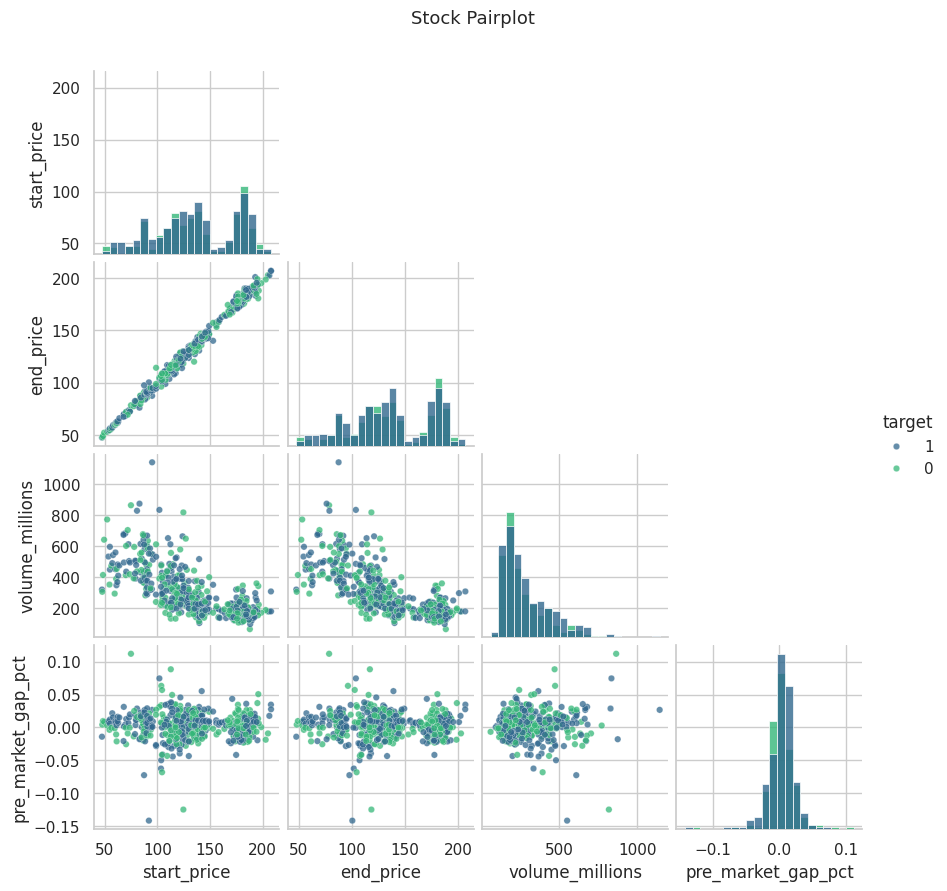

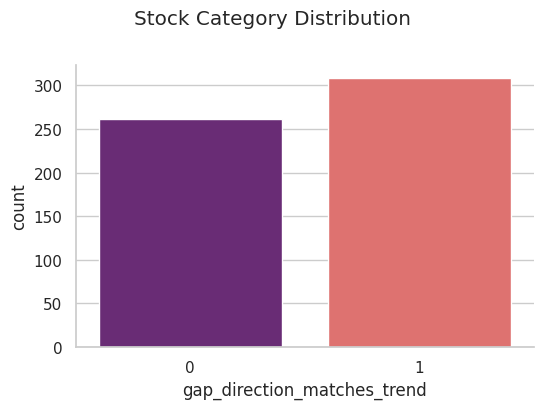


=== Finviz News Dataset EDA ===
Shape: (45775, 4)

Columns: ['datetime', 'headline', 'source', 'trade_date']

Dtypes:
 datetime         str
headline         str
source           str
trade_date    object
dtype: object

First 5 rows:


,datetime,headline,source,trade_date
0,2024-01-01T07:00:00,The Tax Whiz With the Strangest Hustle on Wall...,WSJ,2024-01-01
1,2024-01-01T06:06:00,"Earthquake slams Japan, residents flee some co...",Reuters,2024-01-01
2,2024-01-01T06:02:00,Stock market highs complicate Trump's 2024 mes...,Yahoo,2024-01-01
3,2024-01-01T05:30:00,Optimism Abounds on Wall Street This New Year,WSJ,2024-01-01
4,2024-01-01T05:00:00,Chill in the Housing Market Seeps Into Other I...,THE NY Times,2024-01-01



Missing values (news):
  None found.

Summary statistics (news):


,mean,median,variance
headline_length,63.2930,63,259.9360
hour_of_day,10.6218,11,15.5220
headline_word_count,10.3400,10,7.7666


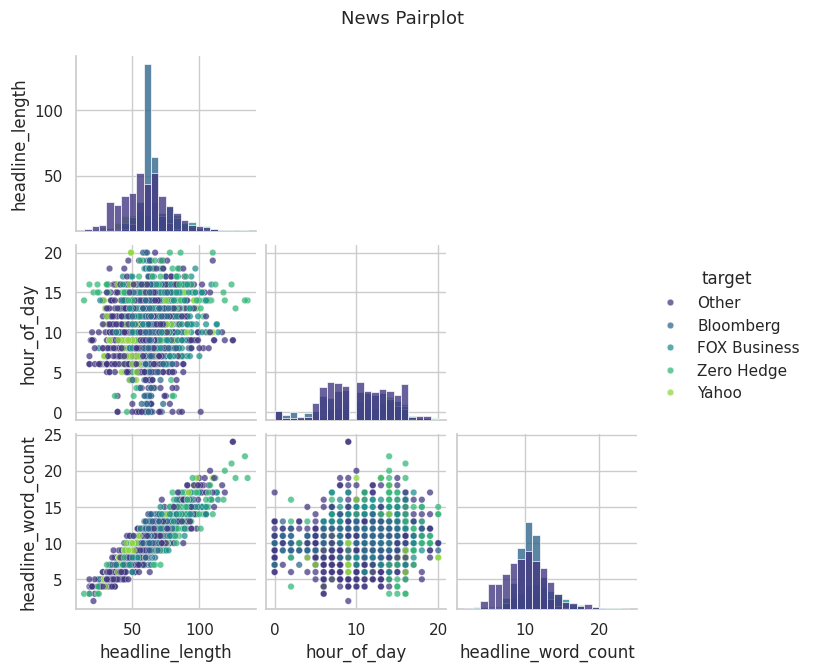

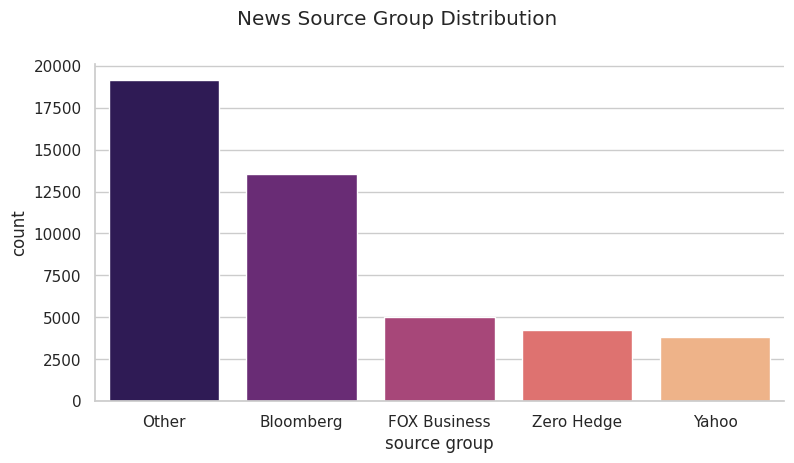

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE  = "viridis"
PLOT_KWS = {"s": 22, "alpha": 0.75, "edgecolor": "white", "linewidth": 0.25}
DIAG_KWS = {"bins": 22, "alpha": 0.8}


def fmt(x):
    # format numbers without scientific notation for cleaner tables
    if pd.isna(x):
        return "NaN"
    x = float(x)
    if x.is_integer():
        return f"{int(x):,}"
    if abs(x) >= 1_000_000:
        return f"{x:,.2f}"
    return f"{x:,.4f}"

def display_clean(df):
    display(df.copy().map(fmt))

def missing_report(df, label):
    counts = df.isna().sum()
    pct    = (counts / len(df) * 100).round(2)
    report = pd.DataFrame({"missing_count": counts, "missing_pct": pct})
    report = report[report["missing_count"] > 0].sort_values("missing_count", ascending=False)
    print(f"\nMissing values ({label}):")
    if report.empty:
        print("  None found.")
    else:
        display_clean(report)

def summary_stats(df, cols, label):
    stats = pd.DataFrame({
        "mean":     df[cols].mean(),
        "median":   df[cols].median(),
        "variance": df[cols].var(),
    }).round(4)
    print(f"\nSummary statistics ({label}):")
    display_clean(stats)

def hide_upper_triangle(g):
    # seaborn pairplot with corner=False shows the full grid by default,
    # so I manually hide upper-triangle panels to keep the layout clean
    for i, j in zip(*np.triu_indices_from(g.axes, k=1)):
        g.axes[i, j].set_visible(False)


# ── Stock EDA ─────────────────────────────────────────────────────────────────

print("=== Stock Dataset EDA ===")
print("Shape:", stock_df.shape)
print("\nColumns:", stock_df.columns.tolist())
print("\nDtypes:\n", stock_df.dtypes)
print("\nFirst 5 rows:")
display(stock_df.head())

missing_report(stock_df, "stock")

stock_numeric = stock_df.select_dtypes(include="number").columns.tolist()
summary_stats(stock_df, stock_numeric, "stock")

stock_plot = stock_df.copy()
stock_plot["target"]          = stock_plot["gap_direction_matches_trend"].astype(str)
stock_plot["volume_millions"] = stock_plot["volume"] / 1_000_000  # scale to millions for readability

STOCK_VARS = ["start_price", "end_price", "volume_millions", "pre_market_gap_pct"]

g = sns.pairplot(
    stock_plot[STOCK_VARS + ["target"]].dropna(),
    vars=STOCK_VARS,
    hue="target",       # color by whether gap direction matched the trend
    palette=PALETTE,
    corner=False,       # must be False or axis labels get dropped on diagonal panels
    diag_kind="hist",
    height=2.2,
    plot_kws=PLOT_KWS,
    diag_kws=DIAG_KWS,
)
hide_upper_triangle(g)
g.figure.suptitle("Stock Pairplot", y=1.01, fontsize=13)
g.figure.subplots_adjust(top=0.94)
plt.show()

# count plot to see class balance in the target variable
g2 = sns.catplot(
    data=stock_plot,
    x="gap_direction_matches_trend",
    hue="target",
    kind="count",
    palette="magma",
    height=4,
    aspect=1.4,
)
g2.set_axis_labels("gap_direction_matches_trend", "count")
g2.figure.suptitle("Stock Category Distribution", y=1.02)
g2.figure.subplots_adjust(top=0.88)
plt.show()


# ── News EDA ──────────────────────────────────────────────────────────────────

print("\n=== Finviz News Dataset EDA ===")
print("Shape:", news_df.shape)
print("\nColumns:", news_df.columns.tolist())
print("\nDtypes:\n", news_df.dtypes)
print("\nFirst 5 rows:")
display(news_df.head())

missing_report(news_df, "news")

news = news_df.copy()
dt = pd.to_datetime(news["datetime"], errors="coerce")

# engineer numeric features from raw text and datetime fields
news["headline_length"]     = news["headline"].astype(str).str.len()
news["hour_of_day"]         = dt.dt.hour
news["headline_word_count"] = news["headline"].astype(str).str.split().str.len()

NEWS_VARS = ["headline_length", "hour_of_day", "headline_word_count"]
summary_stats(news, NEWS_VARS, "news")

# group rare sources into "Other" so the legend stays readable
top_sources    = news["source"].value_counts().head(4).index.tolist()
news["target"] = news["source"].where(news["source"].isin(top_sources), "Other")
target_order   = news["target"].value_counts().index.tolist()

# subsample to 2000 rows so the pairplot renders in reasonable time
g3 = sns.pairplot(
    news[NEWS_VARS + ["target"]].dropna().head(2000),
    vars=NEWS_VARS,
    hue="target",
    hue_order=target_order,
    palette=PALETTE,
    corner=False,
    diag_kind="hist",
    height=2.2,
    plot_kws=PLOT_KWS,
    diag_kws=DIAG_KWS,
)
hide_upper_triangle(g3)
g3.figure.suptitle("News Pairplot", y=1.01, fontsize=13)
g3.figure.subplots_adjust(top=0.94)
plt.show()

# show how many headlines came from each source group
g4 = sns.catplot(
    data=news,
    x="target",
    hue="target",
    order=target_order,
    hue_order=target_order,
    kind="count",
    palette="magma",
    height=4.5,
    aspect=1.8,
)
g4.set_axis_labels("source group", "count")
g4.figure.suptitle("News Source Group Distribution", y=1.02)
g4.figure.subplots_adjust(top=0.9, bottom=0.15)
plt.show()

### Findings


<a id="stock-data-takeaways"></a>
#### Stock Data Takeaways
For the stock data, the biggest structural finding is that `start_price` and `end_price` are near-collinear. One should likely be engineered into a return-based feature instead of keeping both raw variables.

The target classes overlap heavily across the feature space, so this is a genuinely hard classification problem. Non-linear models will likely be necessary to capture useful signal.

<a id="news-data-takeaways"></a>
#### News Data Takeaways
For the news data, `headline_length` and `headline_word_count` are redundant with each other, so one should likely be removed.

No structural metadata feature alone separates sources well, so text-level features will be needed for meaningful downstream performance.

<a id="overall-conclusion"></a>
#### Overall Conclusion
The combined EDA indicates that price features need collinearity-aware engineering, while news features need richer text representations before modeling.

### Step 3: Histogram Visualization
This block visualizes numeric feature distributions with histograms so spread, skew, and unusual ranges are easy to spot quickly.

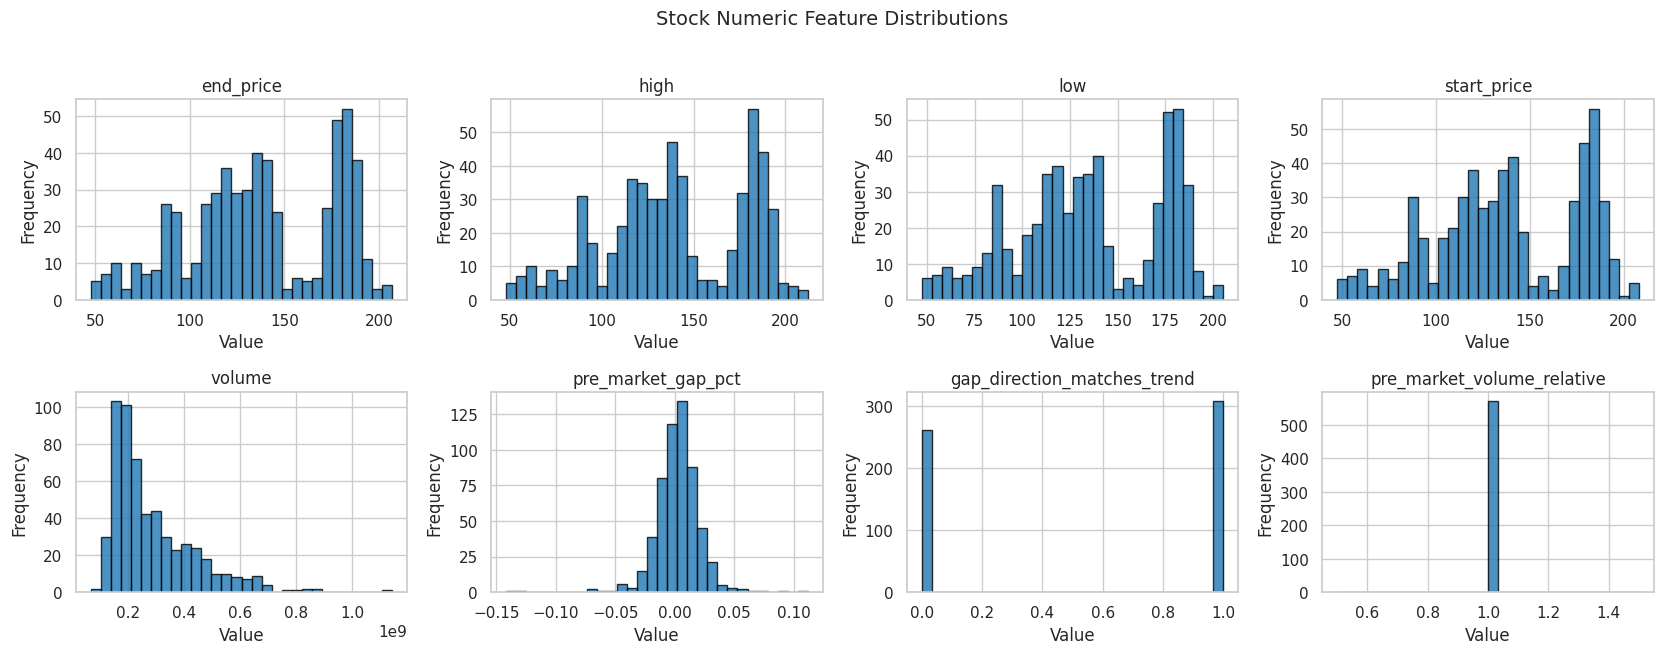

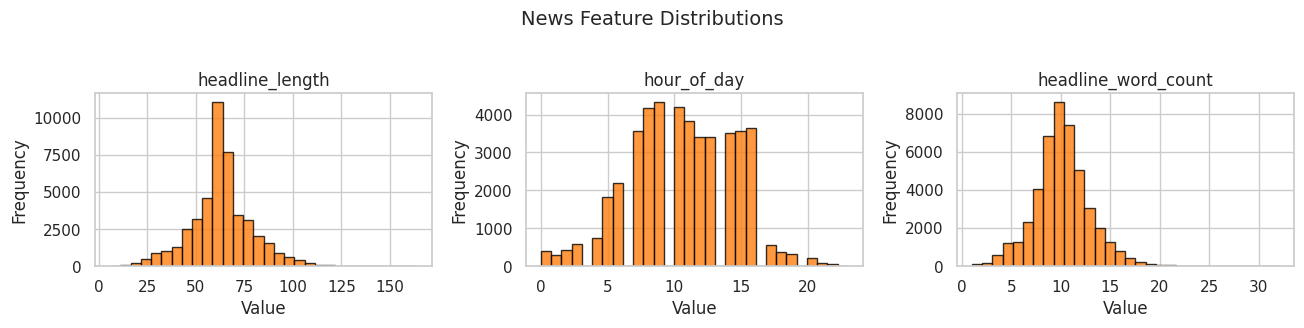

In [9]:
# Step 3: Histogram visualization
import math

# ----- Stock histograms -----
stock_numeric_cols = df.select_dtypes(include="number").columns.tolist()

if stock_numeric_cols:
    n_cols = 4
    n_rows = math.ceil(len(stock_numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(stock_numeric_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor="black", color="#1f77b4", alpha=0.8)
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(len(stock_numeric_cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Stock Numeric Feature Distributions", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()
else:
    print("No numeric columns available for stock histogram plotting.")

# ----- News histograms -----
news_hist = news_df.copy()
news_dt = pd.to_datetime(news_hist["datetime"], errors="coerce")
news_hist["headline_length"] = news_hist["headline"].astype(str).str.len()
news_hist["hour_of_day"] = news_dt.dt.hour
news_hist["headline_word_count"] = news_hist["headline"].astype(str).str.split().str.len()

news_numeric_cols = ["headline_length", "hour_of_day", "headline_word_count"]
news_plot_df = news_hist[news_numeric_cols].dropna()

if not news_plot_df.empty:
    n_cols = 3
    n_rows = math.ceil(len(news_numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.2 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(news_numeric_cols):
        axes[i].hist(news_plot_df[col], bins=30, edgecolor="black", color="#ff7f0e", alpha=0.8)
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(len(news_numeric_cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("News Feature Distributions", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()
else:
    print("No numeric news features available for histogram plotting.")

### Histogram Findings

#### Stock Histogram Findings
1. **Core Price Variables (`start_price`, `high`, `low`, `end_price`)**
   The distributions show a clear **bimodal structure**, indicating NVDA traded across **two dominant price regimes** during the sampled period rather than around a single long-run level.

2. **Daily Trading Volume (`volume`)**
   Volume is **strongly right-skewed**. Most sessions concentrate at lower-to-mid activity levels, while a long upper tail reflects occasional **high-liquidity spikes** tied to event-driven trading.

3. **Pre-market Gap Percentage (`pre_market_gap_pct`)**
   The gap distribution is **approximately normal** and tightly centered near **0**, suggesting overnight moves are usually modest. Large positive or negative gaps appear infrequently.

4. **Gap/Trend Match Indicator (`gap_direction_matches_trend`)**
   This binary feature appears **near-balanced**, with a slight tilt toward positive matches. That is useful because the class distribution is not severely imbalanced at baseline.

5. **Relative Pre-market Volume (`relative_pre_market_volume`)**
   The sharp spike at **1.0** is an **imputation artifact** from preprocessing: missing intraday history was filled with a neutral baseline of 1.0 to preserve chronological continuity without injecting synthetic variation.

#### News Histogram Findings
1. **Headline Length**
   The distribution is approximately **bell-shaped**, with most headlines between **50-80 characters** and a peak around **60-70**. Very short (<30) and very long (>100) headlines are uncommon, suggesting a consistent editorial style optimized for readability.

2. **Hour of Day**
   The time-of-day distribution is **clustered rather than uniform**. Most publishing occurs between **6 AM and 4 PM**, with the highest concentration in the **8 AM-12 PM** window and minimal late-night activity (0-4 AM). This mirrors real-world business news cycles.

3. **Headline Word Count**
   Word count is also roughly **bell-shaped**, centered around **9-11 words**, with most headlines in the **7-13 word** range. Extremely short (<5) and long (>17) headlines are rare, indicating tight control over brevity and clarity.

#### Overall Insights
- The dataset appears **well-structured and stylistically consistent**, with relatively low variance in headline format.
- Strong central tendency in both headline length and word count suggests predictable text structure, which is often beneficial for downstream modeling.
- The hour-of-day pattern captures behavioral dynamics and can support feature engineering such as **`is_peak_hour`**, as well as analyses related to engagement and sentiment shifts.

### Step 4: Correlation and Outliers
This block measures relationships between numeric features using a correlation heatmap, then flags unusual values with an IQR based outlier count.

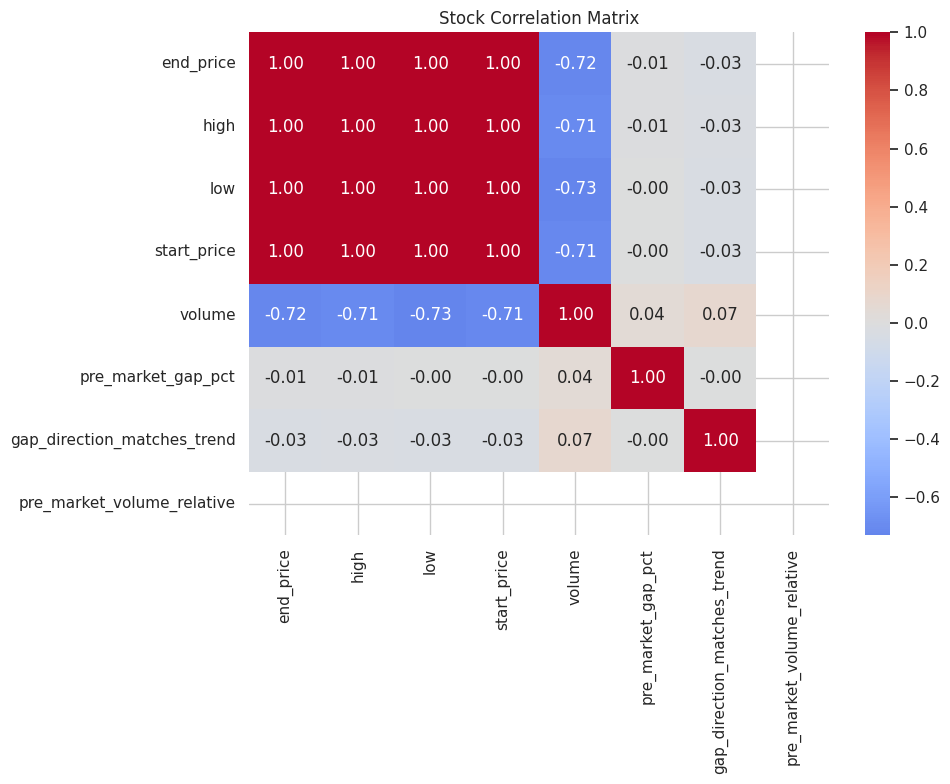

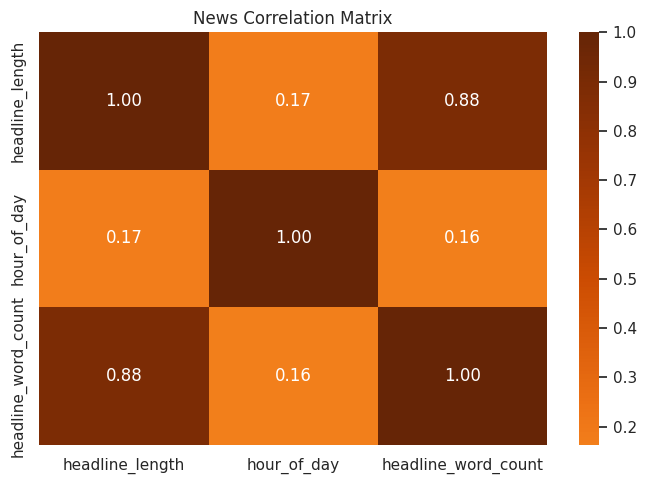

Outlier counts by stock column:


,outlier_count
pre_market_gap_pct,23
volume,21
end_price,0
high,0
start_price,0
low,0
gap_direction_matches_trend,0
pre_market_volume_relative,0


In [10]:
# Step 4: Correlation analysis and outlier detection

# Build a correlation matrix for stock numeric features
if numeric_cols:
    corr_matrix = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Stock Correlation Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for stock correlation analysis.")

# Build a correlation matrix for engineered news numeric features
news_corr_df = news_df.copy()
news_corr_dt = pd.to_datetime(news_corr_df["datetime"], errors="coerce")
news_corr_df["headline_length"] = news_corr_df["headline"].astype(str).str.len()
news_corr_df["hour_of_day"] = news_corr_dt.dt.hour
news_corr_df["headline_word_count"] = news_corr_df["headline"].astype(str).str.split().str.len()

news_corr_cols = ["headline_length", "hour_of_day", "headline_word_count"]
news_corr_matrix = news_corr_df[news_corr_cols].dropna().corr()

if not news_corr_matrix.empty:
    plt.figure(figsize=(7, 5))
    sns.heatmap(news_corr_matrix, annot=True, fmt=".2f", cmap="YlOrBr", center=0)
    plt.title("News Correlation Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for news correlation analysis.")

# Detect outliers using the IQR rule (stock features)
if numeric_cols:
    outlier_counts = {}
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

    outlier_report = (
        pd.Series(outlier_counts, name="outlier_count")
        .sort_values(ascending=False)
        .to_frame()
    )
    print("Outlier counts by stock column:")
    display(outlier_report)
else:
    print("No numeric columns available for outlier detection.")

### Step 5: FinBERT Preparation
This block uses the exact Finviz news table and the headline column to prepare sentiment input.

In [ ]:
# Step 5: FinBERT preparation as a standalone block

# This block prepares text input for FinBERT without forcing model download in run-all mode.
# Uncomment the installation line only if transformers is not installed.
# pip install transformers torch

# Use the exact news table and headline column for FinBERT input
text_source_df = news_df
text_col = "headline"

finbert_input = text_source_df[[text_col]].dropna().copy()
finbert_input[text_col] = finbert_input[text_col].astype(str).str.strip()
finbert_input = finbert_input[finbert_input[text_col] != ""]

print(f"Prepared {len(finbert_input)} text rows from column: {text_col}")
display(finbert_input.head())

# Example FinBERT inference commands kept as comments to avoid auto execution cost
# from transformers import pipeline
# sentiment_pipe = pipeline("text-classification", model="ProsusAI/finbert")
# finbert_input["sentiment"] = finbert_input[text_col].apply(
#     lambda x: sentiment_pipe(x[:512])[0]["label"]
# )
# finbert_input.to_csv(processed_dir / "finbert_sentiment_output.csv", index=False)

: 

: 

## <span style="color:#B45309;">D2.3: Data Wrangling</span>

### Step 6: Wrangle Polymarket Daily Labels
This block cleans the consolidated Polymarket daily open/close file, engineers a daily direction label, aligns dates with stock data, and saves merge-ready artifacts in `data/processed`.

In [16]:
# Step 6: Data wrangling for Polymarket + stock alignment
from pathlib import Path

import pandas as pd

project_root = Path("..")
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

poly_raw_path = processed_dir / "polymarket_daily_open_close_backfill.csv"
poly_clean_path = processed_dir / "polymarket_daily_open_close_backfill_clean.csv"
merge_preview_path = processed_dir / "nvda_stock_with_polymarket_preview.csv"

if not poly_raw_path.exists():
    raise FileNotFoundError(
        f"Missing Polymarket backfill file: {poly_raw_path}. Run the D2.1.1 backfill cell first."
    )

poly_df = pd.read_csv(poly_raw_path)
required_cols = ["date", "open_price", "close_price", "open_time_et", "close_time_et", "event_query"]
missing_cols = [c for c in required_cols if c not in poly_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in backfill CSV: {missing_cols}")

poly_df["trade_date"] = pd.to_datetime(poly_df["date"], errors="coerce").dt.date
poly_df["open_price"] = pd.to_numeric(poly_df["open_price"], errors="coerce")
poly_df["close_price"] = pd.to_numeric(poly_df["close_price"], errors="coerce")

rows_before = len(poly_df)
poly_df = poly_df.dropna(subset=["trade_date", "open_price", "close_price"]).copy()
poly_df = (
    poly_df.sort_values("trade_date")
    .drop_duplicates(subset=["trade_date"], keep="last")
    .reset_index(drop=True)
)

# Binary target for Polymarket direction and daily return
poly_df["pm_direction_up"] = (poly_df["close_price"] > poly_df["open_price"]).astype(int)
poly_df["pm_return"] = (
    (poly_df["close_price"] - poly_df["open_price"])
    / poly_df["open_price"].replace(0, pd.NA)
)
poly_df["pm_return"] = pd.to_numeric(poly_df["pm_return"], errors="coerce")

# Align stock rows on trading date for merge preview
stock_wrangled = stock_df.copy()
stock_wrangled["trade_date"] = pd.to_datetime(stock_wrangled["datetime"], errors="coerce").dt.date
stock_wrangled = (
    stock_wrangled.dropna(subset=["trade_date"])
    .sort_values("trade_date")
    .drop_duplicates(subset=["trade_date"], keep="last")
    .reset_index(drop=True)
)

merge_preview = stock_wrangled.merge(
    poly_df[[
        "trade_date",
        "open_price",
        "close_price",
        "pm_direction_up",
        "pm_return",
        "event_query",
    ]],
    on="trade_date",
    how="left",
)

coverage_pct = merge_preview["pm_direction_up"].notna().mean() * 100

poly_df.to_csv(poly_clean_path, index=False)
merge_preview.to_csv(merge_preview_path, index=False)

print(f"Polymarket rows before cleaning: {rows_before}")
print(f"Polymarket rows after cleaning: {len(poly_df)}")
print(f"Stock rows in merge preview: {len(merge_preview)}")
print(f"Polymarket coverage over stock dates: {coverage_pct:.2f}%")
print(f"Saved clean Polymarket labels: {poly_clean_path}")
print(f"Saved stock/polymarket merge preview: {merge_preview_path}")

display(poly_df.head())
display(merge_preview[["trade_date", "open_price", "close_price", "pm_direction_up", "pm_return"]].head())

Polymarket rows before cleaning: 120
Polymarket rows after cleaning: 120
Stock rows in merge preview: 570
Polymarket coverage over stock dates: 21.05%
Saved clean Polymarket labels: ../data/processed/polymarket_daily_open_close_backfill_clean.csv
Saved stock/polymarket merge preview: ../data/processed/nvda_stock_with_polymarket_preview.csv


,date,open_price,close_price,open_time_et,close_time_et,event_query,matched_event,trade_date,pm_direction_up,pm_return
0,2025-10-15,0.405,0.0245,2025-10-15 10:00:04,2025-10-15 15:00:14,NVIDIA (NVDA) Up or Down on October 15,NVIDIA (NVDA) Up or Down - October 15,2025-10-15,0,-0.939506
1,2025-10-16,0.720,0.7550,2025-10-16 10:00:16,2025-10-16 15:00:15,NVIDIA (NVDA) Up or Down on October 16,NVIDIA (NVDA) Up or Down on October 16?,2025-10-16,1,0.048611
2,2025-10-17,0.400,0.8900,2025-10-17 10:00:19,2025-10-17 15:00:23,NVIDIA (NVDA) Up or Down on October 17,NVIDIA (NVDA) Up or Down on October 17?,2025-10-17,1,1.225000
3,2025-10-20,0.560,0.8300,2025-10-20 10:00:11,2025-10-20 15:00:18,NVIDIA (NVDA) Up or Down on October 20,NVIDIA (NVDA) Up or Down on October 20?,2025-10-20,1,0.482143
4,2025-10-21,0.240,0.1450,2025-10-21 10:00:09,2025-10-21 15:00:14,NVIDIA (NVDA) Up or Down on October 21,NVIDIA (NVDA) Up or Down on October 21?,2025-10-21,0,-0.395833


,trade_date,open_price,close_price,pm_direction_up,pm_return
0,2024-01-02,NaN,NaN,NaN,NaN
1,2024-01-03,NaN,NaN,NaN,NaN
2,2024-01-04,NaN,NaN,NaN,NaN
3,2024-01-05,NaN,NaN,NaN,NaN
4,2024-01-08,NaN,NaN,NaN,NaN


### Findings: D2.3 Wrangling
- **Output summary:** Cleaned Polymarket backfill labels were generated per trade date and aligned with stock rows in a merge preview table.
- **Data-quality checks:** validated required columns, removed invalid numeric/date rows, de-duplicated by `trade_date`, and reported label coverage over stock dates.
- **Artifacts saved to `data/processed`:** `polymarket_daily_open_close_backfill_clean.csv` and `nvda_stock_with_polymarket_preview.csv`.
- **Interpretation:** the dataset is now merge-ready for downstream feature engineering and final label-selection decisions.

## <span style="color:#7C3AED;">D2.4: Feature Engineering</span>

### How Data Was Combined (End-to-End)

This project combines stock context and Polymarket odds in a staged pipeline so every transformation is traceable and reproducible.

1. **Raw ingestion (D2.2 Step 1):**
   - Stock context is loaded from `data/raw/NVDA_prices_features_2024-01-01_to_2026-04-13.json`.
   - News is loaded from `data/raw/finviz_2426.json`.
   - `trade_date` is derived from timestamps to create a common join key.

2. **Polymarket backfill (D2.1.1):**
   - `scripts/polymarket_extractor.py` is run in `backfill` mode for the stock-date window.
   - Outputs:
     - `polymarket_daily_open_close_backfill.csv` (daily open/close odds)
     - `polymarket_intraday_mispricing_backfill.csv` (intraday up/down odds with 60-minute forward labels)
     - `polymarket_backfill_missing_dates.csv` (dates with no matching market)

3. **Daily label wrangling (D2.3):**
   - Daily Polymarket rows are cleaned, deduplicated by `trade_date`, and converted to numeric fields.
   - Daily target labels are created: `pm_direction_up` and `pm_return`.
   - Stock rows are normalized to one row per `trade_date` and left-joined with Polymarket labels.
   - Output: `nvda_stock_with_polymarket_preview.csv`.

4. **Model feature engineering (D2.4 code below):**
   - **Daily model table:** rolling/lagged stock features + daily Polymarket target.
   - **Intraday model table:** microstructure/time-of-day features + 60-minute target (`target_up_move_h60m`) and mispricing fields.

5. **Single master dataset (D2.4 code below):**
   - The intraday model table is merged with richer daily context fields on `trade_date`.
   - Final one-file artifact: `data/processed/polymarket_master_dataset_h60m.csv`.
   - This is the recommended single training table when you want one file with both intraday targets and daily context.

In [19]:
# Step 7: Feature engineering for daily and intraday model tables
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path("..")
processed_dir = project_root / "data" / "processed"

daily_merge_path = processed_dir / "nvda_stock_with_polymarket_preview.csv"
intraday_raw_path = processed_dir / "polymarket_intraday_mispricing_backfill.csv"
daily_features_path = processed_dir / "nvda_daily_model_features.csv"

if not daily_merge_path.exists():
    raise FileNotFoundError(
        f"Missing merge preview file: {daily_merge_path}. Run D2.3 first."
    )
if not intraday_raw_path.exists():
    raise FileNotFoundError(
        f"Missing intraday backfill file: {intraday_raw_path}. Run D2.1.1 first."
    )

daily = pd.read_csv(daily_merge_path)
intraday = pd.read_csv(intraday_raw_path)

# Detect horizon-specific columns produced by the extractor (e.g., h60m).
future_return_col = next((c for c in intraday.columns if c.startswith("future_return_")), None)
future_up_price_col = next((c for c in intraday.columns if c.startswith("future_up_price_")), None)
target_col = next((c for c in intraday.columns if c.startswith("target_up_move_")), None)
if not all([future_return_col, future_up_price_col, target_col]):
    raise ValueError(
        "Intraday file is missing required target columns: future_return_*, future_up_price_*, target_up_move_*"
    )

horizon_suffix = target_col.replace("target_up_move_", "")
intraday_features_path = processed_dir / f"nvda_intraday_mispricing_features_{horizon_suffix}.csv"
master_dataset_path = processed_dir / f"polymarket_master_dataset_{horizon_suffix}.csv"
underpriced_col = f"is_underpriced_up_{horizon_suffix}"
overpriced_col = f"is_overpriced_up_{horizon_suffix}"
edge_col = f"realized_edge_{horizon_suffix}"

daily["trade_date"] = pd.to_datetime(daily["trade_date"], errors="coerce")
intraday["trade_date"] = pd.to_datetime(intraday["trade_date"], errors="coerce")
intraday["timestamp_et"] = pd.to_datetime(intraday["timestamp_et"], errors="coerce")

daily_numeric = [
    "start_price",
    "end_price",
    "high",
    "low",
    "volume",
    "pre_market_gap_pct",
    "pre_market_volume_relative",
    "gap_direction_matches_trend",
    "open_price",
    "close_price",
    "pm_direction_up",
    "pm_return",
]
for col in daily_numeric:
    if col in daily.columns:
        daily[col] = pd.to_numeric(daily[col], errors="coerce")

intraday_numeric = ["up_price", "down_price", future_up_price_col, future_return_col, target_col]
for col in intraday_numeric:
    if col in intraday.columns:
        intraday[col] = pd.to_numeric(intraday[col], errors="coerce")

daily = daily.sort_values("trade_date").reset_index(drop=True)
intraday = intraday.sort_values(["trade_date", "timestamp_et"]).reset_index(drop=True)

# Daily (end-of-day) feature set.
daily["stock_return_1d"] = (daily["end_price"] - daily["start_price"]) / daily["start_price"].replace(0, np.nan)
daily["high_low_range_pct"] = (daily["high"] - daily["low"]) / daily["start_price"].replace(0, np.nan)
daily["close_pos_in_range"] = (daily["end_price"] - daily["low"]) / (daily["high"] - daily["low"]).replace(0, np.nan)
daily["log_volume"] = np.log1p(daily["volume"].clip(lower=0))
daily["stock_return_lag1"] = daily["stock_return_1d"].shift(1).fillna(0.0)
daily["stock_return_lag2"] = daily["stock_return_1d"].shift(2).fillna(0.0)
daily["ret_mean_5d"] = daily["stock_return_1d"].rolling(5, min_periods=1).mean()
daily["ret_std_5d"] = daily["stock_return_1d"].rolling(5, min_periods=2).std().fillna(0.0)
daily["vol_mean_5d"] = daily["volume"].rolling(5, min_periods=1).mean()
daily["volume_vs_5d"] = daily["volume"] / daily["vol_mean_5d"].replace(0, np.nan)
daily["volume_vs_5d"] = daily["volume_vs_5d"].replace([np.inf, -np.inf], np.nan).fillna(1.0)

daily["pm_direction_up"] = daily["pm_direction_up"].where(daily["pm_direction_up"].isin([0, 1]))
daily_model = daily.dropna(subset=["trade_date", "pm_direction_up"]).copy()
daily_model["pm_direction_up"] = daily_model["pm_direction_up"].astype(int)

daily_feature_cols = [
    "start_price",
    "end_price",
    "high",
    "low",
    "volume",
    "pre_market_gap_pct",
    "pre_market_volume_relative",
    "gap_direction_matches_trend",
    "stock_return_1d",
    "high_low_range_pct",
    "close_pos_in_range",
    "log_volume",
    "stock_return_lag1",
    "stock_return_lag2",
    "ret_mean_5d",
    "ret_std_5d",
    "volume_vs_5d",
]
daily_keep_cols = [col for col in daily_feature_cols if col in daily_model.columns]
daily_tail_cols = [col for col in ["pm_direction_up", "pm_return", "event_query"] if col in daily_model.columns]
daily_model = daily_model[["trade_date"] + daily_keep_cols + daily_tail_cols]
daily_model["trade_date"] = daily_model["trade_date"].dt.date.astype(str)

# Intraday (mispricing) feature set.
intraday["minute_from_open"] = (
    intraday["timestamp_et"].dt.hour * 60 + intraday["timestamp_et"].dt.minute - (9 * 60 + 30)
).clip(lower=0, upper=390)
intraday["minute_sin"] = np.sin(2 * np.pi * intraday["minute_from_open"] / 390.0)
intraday["minute_cos"] = np.cos(2 * np.pi * intraday["minute_from_open"] / 390.0)

intraday["up_ret_1"] = intraday.groupby("trade_date")["up_price"].pct_change().fillna(0.0)
intraday["up_ret_3"] = intraday.groupby("trade_date")["up_price"].pct_change(3).fillna(0.0)
intraday["up_sma_5"] = intraday.groupby("trade_date")["up_price"].transform(
    lambda s: s.rolling(5, min_periods=1).mean()
)
intraday["up_std_5"] = intraday.groupby("trade_date")["up_price"].transform(
    lambda s: s.rolling(5, min_periods=2).std()
).fillna(0.0)
intraday["up_vs_sma_5"] = intraday["up_price"] / intraday["up_sma_5"].replace(0, np.nan) - 1.0
intraday["up_vs_sma_5"] = intraday["up_vs_sma_5"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Add same-day stock context so intraday mispricing models can use market-state features.
daily_context_cols = [
    "trade_date",
    "pre_market_gap_pct",
    "pre_market_volume_relative",
    "gap_direction_matches_trend",
    "stock_return_1d",
    "high_low_range_pct",
    "volume_vs_5d",
]
context_cols_available = [col for col in daily_context_cols if col in daily.columns]
intraday = intraday.merge(daily[context_cols_available], on="trade_date", how="left")

intraday[underpriced_col] = intraday[target_col]
intraday[overpriced_col] = 1 - intraday[target_col]
intraday[edge_col] = intraday[future_up_price_col] - intraday["up_price"]

intraday_model = intraday.dropna(subset=["trade_date", "timestamp_et", future_return_col, target_col]).copy()
intraday_model[target_col] = intraday_model[target_col].astype(int)
intraday_model[underpriced_col] = intraday_model[underpriced_col].astype(int)
intraday_model[overpriced_col] = intraday_model[overpriced_col].astype(int)

intraday_feature_cols = [
    "up_price",
    "down_price",
    "minute_from_open",
    "minute_sin",
    "minute_cos",
    "up_ret_1",
    "up_ret_3",
    "up_sma_5",
    "up_std_5",
    "up_vs_sma_5",
    "pre_market_gap_pct",
    "pre_market_volume_relative",
    "gap_direction_matches_trend",
    "stock_return_1d",
    "high_low_range_pct",
    "volume_vs_5d",
]
intraday_keep_cols = [col for col in intraday_feature_cols if col in intraday_model.columns]
intraday_tail_cols = [
    col
    for col in [future_return_col, target_col, underpriced_col, overpriced_col, edge_col, "event_query", "matched_event"]
    if col in intraday_model.columns
]
intraday_model = intraday_model[["trade_date", "timestamp_et"] + intraday_keep_cols + intraday_tail_cols]
intraday_model["trade_date"] = intraday_model["trade_date"].dt.date.astype(str)
intraday_model["timestamp_et"] = intraday_model["timestamp_et"].dt.strftime("%Y-%m-%d %H:%M:%S")

# One-file master dataset: intraday labels + richer daily context fields.
daily_extra_cols = [
    "trade_date",
    "start_price",
    "end_price",
    "high",
    "low",
    "volume",
    "stock_return_lag1",
    "stock_return_lag2",
    "ret_mean_5d",
    "ret_std_5d",
    "log_volume",
    "close_pos_in_range",
    "pm_direction_up",
    "pm_return",
]
daily_extra_cols = [c for c in daily_extra_cols if c in daily_model.columns]
daily_extra = daily_model[daily_extra_cols].drop_duplicates(subset=["trade_date"]).copy()
master_dataset = intraday_model.merge(daily_extra, on="trade_date", how="left")

daily_model.to_csv(daily_features_path, index=False)
intraday_model.to_csv(intraday_features_path, index=False)
master_dataset.to_csv(master_dataset_path, index=False)

print(f"Daily model rows: {len(daily_model)} | columns: {len(daily_model.columns)}")
print(f"Intraday model rows ({horizon_suffix}): {len(intraday_model)} | columns: {len(intraday_model.columns)}")
print(f"Master dataset rows ({horizon_suffix}): {len(master_dataset)} | columns: {len(master_dataset.columns)}")
print(f"Daily positive rate (pm_direction_up): {daily_model['pm_direction_up'].mean():.3f}")
print(f"Intraday positive rate ({target_col}): {intraday_model[target_col].mean():.3f}")
print(f"Saved daily features: {daily_features_path}")
print(f"Saved intraday features: {intraday_features_path}")
print(f"Saved master dataset: {master_dataset_path}")

display(daily_model.head())
display(intraday_model.head())
display(master_dataset.head())

Daily model rows: 120 | columns: 21
Intraday model rows (h60m): 503 | columns: 25
Master dataset rows (h60m): 503 | columns: 38
Daily positive rate (pm_direction_up): 0.483
Intraday positive rate (target_up_move_h60m): 0.497
Saved daily features: ../data/processed/nvda_daily_model_features.csv
Saved intraday features: ../data/processed/nvda_intraday_mispricing_features_h60m.csv
Saved master dataset: ../data/processed/polymarket_master_dataset_h60m.csv


,trade_date,start_price,end_price,high,low,volume,pre_market_gap_pct,pre_market_volume_relative,gap_direction_matches_trend,stock_return_1d,...,close_pos_in_range,log_volume,stock_return_lag1,stock_return_lag2,ret_mean_5d,ret_std_5d,volume_vs_5d,pm_direction_up,pm_return,event_query
448,2025-10-15,184.779712,179.810257,184.849697,177.270527,214450500,0.026496,1.0,0,-0.026894,...,0.335093,19.183590,-0.025654,0.001862,-0.020480,0.023192,1.045747,0,-0.939506,NVIDIA (NVDA) Up or Down on October 15
449,2025-10-16,182.209991,181.790039,183.259879,179.750270,179723300,0.013346,1.0,0,-0.002305,...,0.581196,19.006929,-0.026894,-0.025654,-0.021295,0.022268,0.879210,1,0.048611,NVIDIA (NVDA) Up or Down on October 16
450,2025-10-17,180.160215,183.199890,184.079798,179.730270,173135200,-0.008965,1.0,1,0.016872,...,0.797700,18.969583,-0.002305,-0.026894,-0.007224,0.018801,0.934418,1,1.225000,NVIDIA (NVDA) Up or Down on October 17
451,2025-10-20,183.109901,182.619949,185.179666,181.710046,128544700,-0.000491,1.0,0,-0.002676,...,0.262249,18.671787,0.016872,-0.002305,-0.008131,0.018357,0.712953,1,0.482143,NVIDIA (NVDA) Up or Down on October 20
452,2025-10-21,182.769917,181.140106,182.769917,179.780255,124240200,0.000821,1.0,0,-0.008917,...,0.454851,18.637727,-0.002676,0.016872,-0.004784,0.015696,0.757475,0,-0.395833,NVIDIA (NVDA) Up or Down on October 21


,trade_date,timestamp_et,up_price,down_price,minute_from_open,minute_sin,minute_cos,up_ret_1,up_ret_3,up_sma_5,...,stock_return_1d,high_low_range_pct,volume_vs_5d,future_return_h60m,target_up_move_h60m,is_underpriced_up_h60m,is_overpriced_up_h60m,realized_edge_h60m,event_query,matched_event
0,2025-10-15,2025-10-15 10:00:04,0.405,0.595,30,0.464723,0.885456,0.000000,0.00000,0.405000,...,-0.026894,0.041017,1.045747,-0.333333,0,0,1,-0.1350,NVIDIA (NVDA) Up or Down on October 15,NVIDIA (NVDA) Up or Down - October 15
1,2025-10-15,2025-10-15 11:00:16,0.270,0.730,90,0.992709,0.120537,-0.333333,0.00000,0.337500,...,-0.026894,0.041017,1.045747,-0.870370,0,0,1,-0.2350,NVIDIA (NVDA) Up or Down on October 15,NVIDIA (NVDA) Up or Down - October 15
2,2025-10-15,2025-10-15 12:00:03,0.155,0.845,150,0.663123,-0.748511,-0.425926,0.00000,0.276667,...,-0.026894,0.041017,1.045747,-0.774194,0,0,1,-0.1200,NVIDIA (NVDA) Up or Down on October 15,NVIDIA (NVDA) Up or Down - October 15
3,2025-10-15,2025-10-15 13:00:20,0.035,0.965,210,-0.239316,-0.970942,-0.774194,-0.91358,0.216250,...,-0.026894,0.041017,1.045747,-0.300000,0,0,1,-0.0105,NVIDIA (NVDA) Up or Down on October 15,NVIDIA (NVDA) Up or Down - October 15
6,2025-10-16,2025-10-16 10:00:16,0.720,0.280,30,0.464723,0.885456,0.000000,0.00000,0.720000,...,-0.002305,0.019261,0.879210,0.125000,1,1,0,0.0900,NVIDIA (NVDA) Up or Down on October 16,NVIDIA (NVDA) Up or Down on October 16?


,trade_date,timestamp_et,up_price,down_price,minute_from_open,minute_sin,minute_cos,up_ret_1,up_ret_3,up_sma_5,...,low,volume,stock_return_lag1,stock_return_lag2,ret_mean_5d,ret_std_5d,log_volume,close_pos_in_range,pm_direction_up,pm_return
0,2025-10-15,2025-10-15 10:00:04,0.405,0.595,30,0.464723,0.885456,0.000000,0.00000,0.405000,...,177.270527,214450500,-0.025654,0.001862,-0.020480,0.023192,19.183590,0.335093,0,-0.939506
1,2025-10-15,2025-10-15 11:00:16,0.270,0.730,90,0.992709,0.120537,-0.333333,0.00000,0.337500,...,177.270527,214450500,-0.025654,0.001862,-0.020480,0.023192,19.183590,0.335093,0,-0.939506
2,2025-10-15,2025-10-15 12:00:03,0.155,0.845,150,0.663123,-0.748511,-0.425926,0.00000,0.276667,...,177.270527,214450500,-0.025654,0.001862,-0.020480,0.023192,19.183590,0.335093,0,-0.939506
3,2025-10-15,2025-10-15 13:00:20,0.035,0.965,210,-0.239316,-0.970942,-0.774194,-0.91358,0.216250,...,177.270527,214450500,-0.025654,0.001862,-0.020480,0.023192,19.183590,0.335093,0,-0.939506
4,2025-10-16,2025-10-16 10:00:16,0.720,0.280,30,0.464723,0.885456,0.000000,0.00000,0.720000,...,179.750270,179723300,-0.026894,-0.025654,-0.021295,0.022268,19.006929,0.581196,1,0.048611


### Findings: D2.4 Feature Engineering
- **Output summary:** Three train-ready outputs were generated from the combined stock + Polymarket pipeline: daily model table, intraday model table, and one consolidated master table.
- **Daily feature table:** `120` rows, `21` columns saved to `data/processed/nvda_daily_model_features.csv` with lag/rolling/volume features and target `pm_direction_up`.
- **Intraday mispricing table:** `503` labeled rows, `25` columns saved to `data/processed/nvda_intraday_mispricing_features_h60m.csv` with horizon target `target_up_move_h60m`, `is_underpriced_up_h60m`, `is_overpriced_up_h60m`, and `realized_edge_h60m`.
- **Single master dataset (recommended one-file output):** `503` rows, `38` columns saved to `data/processed/polymarket_master_dataset_h60m.csv`, combining intraday targets with richer daily context (`start_price`, `end_price`, `high`, `low`, `volume`, lag/rolling stock features, and daily Polymarket labels).
- **Join logic used in final consolidation:** intraday rows were merged with daily-context rows using `trade_date` as the key.
- **Label balance check:** daily positive rate `0.483`; intraday positive rate `0.497` (near-balanced classes for baseline classification).
- **Interpretation:** the notebook now documents and executes the full combination flow end-to-end, and exports a single canonical dataset for modeling while preserving stage-level artifacts for auditability.